# Conditional Poisson Sampling

Suppose you want to draw a random subset of exactly $n$ items from a universe $\mathcal{S}$ of $N$ items, where each item has a weight ${\color{#2196F3}{w_i}} > 0$.  The probability of drawing a particular subset $S \in \tbinom{\mathcal{S}}{n}$ is proportional to the product of its weights:

$$
P(S) = \frac{\prod_{i \in S} {\color{#2196F3}{w_i}}}{{\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}}, \quad S \in \tbinom{\mathcal{S}}{n}
$$

where ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n} = \sum_{S \in \tbinom{\mathcal{S}}{n}} \prod_{i \in S} {\color{#2196F3}{w_i}}$ is the normalizing constant — a weighted generalization of the binomial coefficient (when ${\color{#2196F3}{\boldsymbol{w}}} = \mathbf{1}$, we recover ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n} = \binom{N}{n}$).

This is the **conditional Poisson distribution** (also called the *exponential* fixed-size design).  It arises by running independent Bernoulli trials — include item $i$ with probability $p_i = {\color{#2196F3}{w_i}}/(1+{\color{#2196F3}{w_i}})$ — and conditioning on exactly $n$ items being selected.  The weight ${\color{#2196F3}{w_i}}$ is the *odds* of the $i$-th coin flip: ${\color{#2196F3}{w_i}} = p_i / (1 - p_i)$.

In this post, I'll describe an implementation that computes inclusion probabilities, draws exact samples, and fits weights to target probabilities — all in $O(N \log^2 n)$ time using a polynomial product tree.  The code is available as a single-file library: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling).

**As far as I can tell, this is the only publicly available library for conditional Poisson sampling in Python** (or any language outside of R's survey-sampling packages).  Existing R implementations — `UPmaxentropy` in the [sampling](https://cran.r-project.org/web/packages/sampling/) package and the [BalancedSampling](https://cran.r-project.org/web/packages/BalancedSampling/) package — use either rejection sampling or $O(Nn)$ dynamic programming.  The $O(N \log^2 n)$ product-tree algorithm used here does not appear in any prior software that I'm aware of.

## The rejection sampling construction

There's a beautifully simple way to *define* this distribution that makes it easy to see what it does.  Start with independent Bernoulli sampling: include each item $i$ independently with probability $p_i = {\color{#2196F3}{w_i}}/(1+{\color{#2196F3}{w_i}})$.  The resulting random set has *expected* size $\sum_i p_i$, but its actual size varies.  Now condition on the event that the sample has exactly size $n$.  That's it — that's the conditional Poisson distribution.

This gives us a trivial rejection sampler: draw independent Bernoulli trials and **reject** unless you get exactly $n$ items.  The accepted samples follow exactly $P(S) \propto \prod_{i \in S} {\color{#2196F3}{w_i}}$.

In [1]:
def rejection_sample(w, n, rng):
    """Sample from the conditional Poisson distribution by rejection."""
    p = w / (1 + w)          # Bernoulli inclusion probs
    attempts = 0
    while True:
        attempts += 1
        S = np.where(rng.random(len(w)) < p)[0]
        if len(S) == n:
            return S, attempts

# Demo: it works, but how many attempts does it take?
import numpy as np
rng_rej = np.random.default_rng(42)
N_rej, n_rej = 20, 5
w_rej = rng_rej.exponential(1.0, N_rej)
attempt_counts = []
for _ in range(1000):
    _, att = rejection_sample(w_rej, n_rej, rng_rej)
    attempt_counts.append(att)

print(f'N={N_rej}, n={n_rej}')
print(f'mean attempts per sample: {np.mean(attempt_counts):.1f}')
print(f'max attempts:             {np.max(attempt_counts)}')

N=20, n=5
mean attempts per sample: 19.7
max attempts:             160


The acceptance rate is the probability that independent Bernoulli sampling produces exactly $n$ items:

$$
P(|S| = n) = \frac{{\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}}{\prod_{i=1}^N (1 + {\color{#2196F3}{w_i}})}
$$

So the expected number of rejection attempts is $\prod_i(1 + {\color{#2196F3}{w_i}}) / {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$.  This can be astronomically large — it grows exponentially in $N$ in the worst case.  And rejection sampling gives you no way to compute the normalizing constant ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$, the inclusion probabilities, or gradients for fitting.  That's the gap the product tree fills.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pylab as pl
from conditional_poisson import ConditionalPoisson

## Basic usage

The simplest entry point is `from_weights`: hand it a subset size $n$ and a weight vector ${\color{#2196F3}{\boldsymbol{w}}}$.

In [3]:
N, n = 10, 4
rng = np.random.default_rng(0)
w = rng.exponential(1.0, N)

cp = ConditionalPoisson.from_weights(n, w)
print(f'N={N}, n={n}')
print(f'weights:   {np.round(w, 3)}')
print(f'pi:        {np.round(cp.pi, 3)}')
print(f'sum(pi):   {cp.pi.sum():.6f}  (should be {n})')
print(f'log Z:     {cp.log_normalizer:.4f}')

N=10, n=4
weights:   [6.800e-01 1.020e+00 2.000e-02 2.000e-03 5.500e-01 1.630e+00 6.740e-01
 7.550e-01 2.817e+00 6.058e+00]
pi:        [0.343 0.456 0.013 0.001 0.291 0.592 0.341 0.371 0.73  0.861]
sum(pi):   4.000000  (should be 4)
log Z:     5.7602


The inclusion probabilities ${\color{#E91E63}{\pi_i}} = P(i \in S)$ always sum to $n$, and each ${\color{#E91E63}{\pi_i}} \in (0, 1)$.  Items with larger weights get higher inclusion probabilities.

## Sampling

Drawing samples works by walking a binary tree top-down, splitting a "quota" of $n$ items between the left and right subtrees at each node.  Each split is exact (not approximate), and the tree is built once and cached, so subsequent samples are cheap.

In [4]:
M = 100_000
samples = cp.sample(M, rng=rng)
print(f'sample shape: {samples.shape}')   # (M, n)
print(f'first few samples:')
print(samples[:5])

sample shape: (100000, 4)
first few samples:
[[4 5 7 9]
 [4 5 8 9]
 [4 5 6 8]
 [4 5 8 9]
 [1 5 7 9]]


Let's verify that the empirical inclusion frequencies match the exact ${\color{#E91E63}{\pi}}$ values.

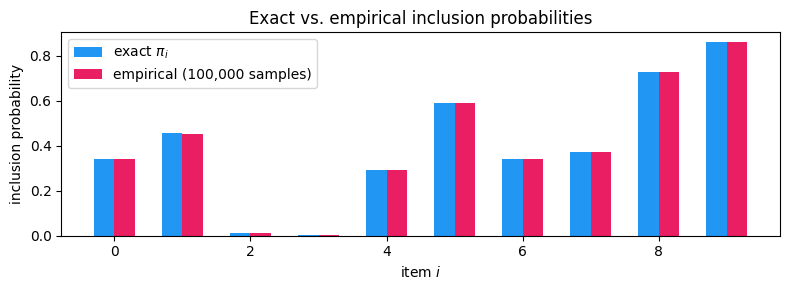

In [5]:
pi_emp = np.bincount(samples.ravel(), minlength=N) / M

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, cp.pi, width=0.3, label='exact $\pi_i$', color='#2196F3')
pl.bar(ix + 0.15, pi_emp, width=0.3, label=f'empirical ({M:,} samples)', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Exact vs. empirical inclusion probabilities')
pl.tight_layout()

## The polynomial product tree

The key idea is to encode the sum over all $\binom{N}{n}$ subsets as the coefficient of $z^n$ in a product of polynomials:

$$
(1 + {\color{#2196F3}{w_1}} z)(1 + {\color{#2196F3}{w_2}} z) \cdots (1 + {\color{#2196F3}{w_N}} z) = \sum_{k=0}^{N} {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{k}\, z^k
$$

The $n$-th coefficient is exactly ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$, the normalizing constant.  This product can be computed in $O(N \log^2 n)$ time using a binary tree — each leaf holds a degree-1 polynomial $(1 + {\color{#2196F3}{w_i}} z)$, and internal nodes multiply their children's polynomials (truncated to degree $n$).

To get the inclusion probability ${\color{#E91E63}{\pi_i}}$, we need the "leave-one-out" product — the product of all factors except factor $i$.  Rather than computing $N$ separate products, a top-down pass propagates "outside" polynomials from the root back to the leaves, reusing the tree.  At leaf $i$:

$$
{\color{#E91E63}{\pi_i}} = {\color{#2196F3}{w_i}} \cdot \llbracket P^{(-i)} \rrbracket(z^{n-1}) \;/\; {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}
$$

where $P^{(-i)}(z) = \prod_{j \neq i}(1 + {\color{#2196F3}{w_j}} z)$ is the leave-one-out polynomial and $\llbracket f \rrbracket(z^k)$ denotes the coefficient of $z^k$ in the formal power series $f$.

This is essentially the same divide-and-conquer structure I described in the [heaps for incremental computation](https://timvieira.github.io/blog/heaps-for-incremental-computation/) post, but over polynomials instead of scalars.

## Brute-force verification

For small instances, we can enumerate all $\binom{N}{n}$ subsets and verify that the efficient algorithm gets the right answer.

In [6]:
from itertools import combinations

N_small, n_small = 7, 3
w_small = rng.exponential(1.0, N_small)
cp_small = ConditionalPoisson.from_weights(n_small, w_small)

# Brute force: enumerate all subsets
all_S = list(combinations(range(N_small), n_small))
log_probs_bf = np.array([np.log(np.prod(w_small[list(s)])) for s in all_S])
log_probs_bf -= np.log(np.exp(log_probs_bf).sum())   # normalise

# Inclusion probabilities from brute force
probs_bf = np.exp(log_probs_bf)
pi_bf = np.zeros(N_small)
for k, s in enumerate(all_S):
    for i in s:
        pi_bf[i] += probs_bf[k]

print(f'max |pi_tree - pi_brute_force| = {np.max(np.abs(cp_small.pi - pi_bf)):.2e}')
print(f'sum P(S) via brute force       = {probs_bf.sum():.10f}')
print(f'log Z: tree={cp_small.log_normalizer:.6f}, brute force={np.log(np.exp(log_probs_bf + cp_small.log_normalizer).sum()):.6f}')

max |pi_tree - pi_brute_force| = 3.33e-16
sum P(S) via brute force       = 1.0000000000
log Z: tree=2.677290, brute force=2.677290


## Fitting weights to target probabilities

A common use case: you know the inclusion probabilities you *want* (e.g., from a survey design or an optimal allocation), and you need to find weights that produce them.

This is a convex optimization problem.  We maximise the log-likelihood

$$
L(\theta) = {\color{#E91E63}{\pi^{*\top}}} \theta - \log {\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}
$$

where $\theta_i = \log {\color{#2196F3}{w_i}}$ are the log-weights.  The gradient is ${\color{#E91E63}{\pi^*}} - {\color{#E91E63}{\pi}}(\theta)$ and the Hessian is $-\text{Cov}[Z]$, the negative covariance matrix of the inclusion indicators.  We use Newton-CG — the Hessian-vector product $\text{Cov}[Z]\, v$ is computed efficiently via the D-tree (a second tree that piggybacks on the P-tree).

In [7]:
# Target: the inclusion probabilities from our earlier example
pi_star = cp.pi.copy()

# Fit from scratch
cp_fit = ConditionalPoisson.fit(pi_star, n, verbose=True)

  iter   0:  max|pi*-pi| = 3.332e-02
  iter   1:  max|pi*-pi| = 2.606e-03
  iter   2:  max|pi*-pi| = 2.036e-05
  iter   3:  max|pi*-pi| = 1.994e-09
  iter   4:  max|pi*-pi| = 1.496e-09
  iter   5:  max|pi*-pi| = 5.607e-15


max |pi_fit - pi_target| = 5.55e-15


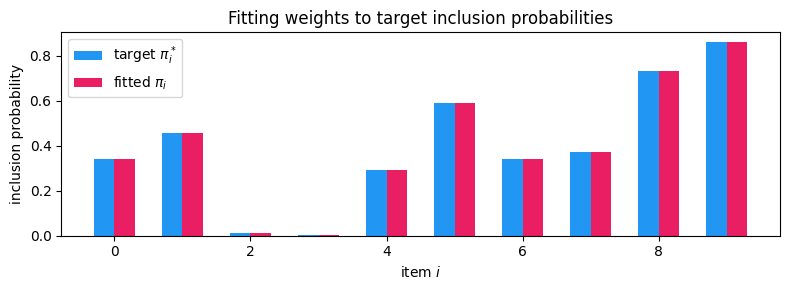

In [8]:
print(f'max |pi_fit - pi_target| = {np.max(np.abs(cp_fit.pi - pi_star)):.2e}')

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, pi_star, width=0.3, label='target $\pi^*_i$', color='#2196F3')
pl.bar(ix + 0.15, cp_fit.pi, width=0.3, label='fitted $\pi_i$', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Fitting weights to target inclusion probabilities')
pl.tight_layout()

## Numerical stability

The implementation handles extreme weight ranges without overflow.  Every polynomial in the tree is stored in a scaled representation `(coeffs, log_scale)` with $\max|c_k| = 1$, so FFT convolutions always operate on $O(1)$-magnitude numbers.  Weights are also geometrically normalised before each tree build.

Let's verify with some stress tests.

In [9]:
cases = [
    ('large positive theta',  ConditionalPoisson(4, rng.uniform(30, 50, 10))),
    ('large negative theta',  ConditionalPoisson(4, rng.uniform(-50, -30, 10))),
    ('wide range theta',      ConditionalPoisson(4, np.linspace(-30, 30, 10))),
    ('N=100, n=50, uniform',  ConditionalPoisson(50, np.full(100, 2.0))),
    ('N=200, n=100, uniform', ConditionalPoisson(100, np.full(200, 10.0))),
    ('N=500, n=250, uniform', ConditionalPoisson(250, np.full(500, 5.0))),
]

print(f'{"case":30s}  {"sum(pi)":>10s}  {"log Z":>12s}  {"ok":>4s}')
print('-' * 62)
for name, cpt in cases:
    pi_t = cpt.pi
    ok = (np.isfinite(pi_t).all() and np.isfinite(cpt.log_normalizer)
          and abs(pi_t.sum() - cpt.n) < 1e-4)
    print(f'{name:30s}  {pi_t.sum():10.4f}  {cpt.log_normalizer:12.2f}  {"✓" if ok else "✗":>4s}')

case                               sum(pi)         log Z    ok
--------------------------------------------------------------
large positive theta                4.0000        172.23     ✓
large negative theta                4.0000       -136.53     ✓
wide range theta                    4.0000         80.00     ✓
N=100, n=50, uniform               50.0000        166.78     ✓
N=200, n=100, uniform             100.0000       1135.75     ✓
N=500, n=250, uniform             250.0000       1593.24     ✓


## Timing

The tree-based approach scales to moderately large $N$ comfortably.

In [10]:
import time

print(f'{"N":>6s}  {"n":>6s}  {"pi (ms)":>10s}  {"hvp (ms)":>10s}  {"10k samples (ms)":>18s}')
print('-' * 56)
for N_t, n_t in [(50, 20), (100, 40), (200, 80), (500, 200)]:
    w_t = rng.exponential(1.0, N_t)
    v_t = rng.standard_normal(N_t)
    cp_t = ConditionalPoisson.from_weights(n_t, w_t)

    reps = max(1, int(800 / (N_t * n_t**0.5)))

    t0 = time.perf_counter()
    for _ in range(reps): cp_t._cache.clear(); cp_t.pi
    pi_ms = (time.perf_counter() - t0) / reps * 1000

    t0 = time.perf_counter()
    for _ in range(reps): cp_t.hvp(v_t)
    hvp_ms = (time.perf_counter() - t0) / reps * 1000

    t0 = time.perf_counter()
    cp_t.sample(10_000, rng=rng)
    samp_ms = (time.perf_counter() - t0) * 1000

    print(f'{N_t:>6d}  {n_t:>6d}  {pi_ms:>10.1f}  {hvp_ms:>10.1f}  {samp_ms:>18.0f}')

     N       n     pi (ms)    hvp (ms)    10k samples (ms)
--------------------------------------------------------
    50      20         3.7         7.7                  35
   100      40        10.0        29.6                  67
   200      80        32.7        93.9                 148
   500     200        77.1       225.5                 364


## Summary

The conditional Poisson distribution is the natural maximum-entropy distribution over fixed-size subsets.  The polynomial product tree gives us an efficient way to compute everything we need:

 * **Upward pass**: builds the product polynomial $\prod_i (1 + {\color{#2196F3}{w_i}} z)$ in a binary tree.  The root's $n$-th coefficient is the normalizing constant ${\color{#FF9800}{Z}}\tbinom{{\color{#2196F3}{\boldsymbol{w}}}}{n}$.

 * **Downward pass**: propagates leave-one-out polynomials to every leaf, giving inclusion probabilities ${\color{#E91E63}{\pi_i}}$ in a single $O(N \log^2 n)$ sweep.

 * **Sampling**: walks the tree top-down, splitting a quota at each node.  Each sample costs $O(n \log N)$.  The tree is built once and reused.

 * **Hessian-vector products**: a second "D-tree" piggybacks on the P-tree, enabling Newton-CG fitting to target inclusion probabilities.

All polynomials use a scaled representation that prevents floating-point overflow even for extreme weights.

Code: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling)

**References:**

- [Hájek (1964)](https://doi.org/10.1214/aoms/1177700375). "Asymptotic Theory of Rejective Sampling with Varying Probabilities from a Finite Population." *The Annals of Mathematical Statistics*, 35(4), 1491–1523.

- [Chen, Dempster & Liu (1994)](https://academic.oup.com/biomet/article-abstract/81/3/457/256956). "Weighted Finite Population Sampling to Maximize Entropy." *Biometrika*, 81(3), 457–469.

- [Tillé (2006)](https://link.springer.com/book/10.1007/978-0-387-34240-0). *Sampling Algorithms*. Springer.

- [Meister, Amini, Vieira & Cotterell (2021)](https://aclanthology.org/2021.emnlp-main.52/). "Conditional Poisson Stochastic Beams." *Proceedings of EMNLP 2021*.